# Energy resolution for an X-ray detector
## Definition of energy resolution
Here we define the energy resolution function for a scintillator,
    but analogous definitions can be made for other types of X-ray or gamma detectors.

Based on the physics of scintillation and the relative contributions of different error types,
    the scintillation energy resolution can usually be written as follows:
$$
    R(E) = \frac{\sqrt{\alpha + \beta E}}{E}
$$

Where $R$ is in percent, $E$ is the energy, and $\alpha$ and $\beta$ are free parameters.
$E$ represents the mean measured energy,
    so the resolution is a percentage of the mean measured value.
The parameters $\alpha$ encodes "extrinsic" factors like baseline electronic noise,
    and the factor $\beta$ encodes Poisson statistics plus intrinsic crystal resolution.

## Measure the energy resolution
Energy resolution is measured from radioactive source data.
It is sometimes a function of temperature and other external factors,
    so this needs to get calibrated.
For a constant temperature, bias voltage, crystal geometry, readout chain, etc.,
    the energy resolution should only depend on the detected photon energy.

We fit a Gaussian function to the line of the form
$$
    f(E) = A \exp\left( - \left[ \frac{(E - \mu)}{\sigma} \right]^2 \right)
$$

$A$, $\sigma$, and $\mu$ are free parameters.
The fit range is important here because the peak is usually skewed,
    either by a Compton scattering tail,
    or by other emission lines leaking in.

For this Gaussian form, the FWHM as a fraction of the mean energy is
$$
\text{FWHM} = \frac{2 \sigma \sqrt{\ln 2}}{\mu}
$$

**This is different from what you will find on Wikipedia**
because there is no factor of 2 in the denominator of the Gaussian argument.

To obtain $\alpha$ and $\beta$ for $R(E)$,
    we fit a curve to several measured values of the FWHM across different energies.

## Applying energy resolution to a detector response
### Formalism: a continuous response
First we will consider a single detector response function before moving to the more realistic matrix case.

Consider a monoenergetic flux of photons with energies $[E_\gamma, E_\gamma + \mathrm d E_\gamma]$.
The energy redistribtuion function $r(E_d)$ encodes the following probability density:
$$
    r(E_d \mid E_\gamma) = p(\text{Photon deposited energy } [E_d, E_d + dE_d] \mid \text{Photon incident at energy }[E_\gamma, E_\gamma + \mathrm d E_\gamma]),
$$
You could compute $r(E_d \mid E_\gamma)$ from a set of mass attenuation coefficients.
The _deposited_ energy is distinct from the _measured_ energy.
To obtain the measured energy,
    we need to (at least) apply the detector energy resolution.
Other effects come into play,
    like the low-energy trigger efficiency,
    but we will focus solely on the energy resolution here.

The energy resolution should be applied as a convolution to the redistribution function. Define the energy resolution kernel as
$$
    g(\varepsilon \mid E_d) = \frac{1}{\sigma(E_d) \sqrt\pi} \exp\left[ -\left(\frac{\varepsilon}{\sigma(E_d)}\right)^2 \right],
$$
where $\sigma(E_d)$ is computed from the fit to measured data.
The function $g(\varepsilon)$ is normalized as a probability density for a given $\sigma$.

To apply the energy resolution to the response function, write
$$
    r^*(E) = \int_{-\infty}^{\infty} r(E_d \mid E_\gamma) g(E - E_d \mid E_d)\ \mathrm d E_d.
$$

The measured energy is $E$ while the deposited energy is $E_d$.
> The convolution has the effect of smearing each point in $r(E_d \mid E_\gamma)$ by a Gaussian function of width $\sigma(E_d)$.

The detector's energy bounds should truncate the integral,
    so we write
$$
    r^*(E) = \int_{E_0}^{E_N} r(E_d \mid E_\gamma) g(E - E_d \mid E_d)\ \mathrm d E_d.
$$

where $E_0$ is the lowest energy bin edge of the detector,
    and $E_N$ is the highest energy bin edge.
$r^*(E)$ describes the following probability density function:
$$
    r^*(E) = p(\text{Count detected at energy }[E, E + \mathrm d E] \mid \text{Photon deposited energy }[E_d, E_d + \mathrm d E_d]).
$$

Because every kernel $g(\varepsilon \mid E_d)$ is a probability density function,
    the total probability contained in the function $r(E)$ is conserved in the full convolution integral,
    and is truncated for the finite bounds.
This truncation is what we want for the response matrix,
    and encodes when a detected count energy falls outside of the bounds of the instrument.

### Application: binned data
For binned data (e.g. count bins and a pixellated response matrix),
    we need to apply the convolution in a different way.
The probability densities $r(E)$ and $g(E)$ must be pixellated into matricies,
    where each entry is a probability which maps an energy range $[E_i, E_{i+1}] \to [E_j, E_{j+1}]$,
    rather than a continuous probability density function.
This is the cost of discretization.

Here we construct a discretely-indexed redistribution matrix $r_{ij}$.
The matrix is square:
    the incident photon energy bins are the same as the deposited energy bins.
Each pixel $r_{ij}$ in the redistribution matrix holds the probability
    of converting an incident photon between energies $[E_{i}, E_{i + 1}]$
    to a deposited energy between $[E_{j}, E_{j + 1}]$;
    the photon energies $E_i$ run along the rows of the matrix,
    and the deposited energies $E_j$ run along the columns.
To convert the continuous functions $r(E_d \mid E_\gamma)$ to matrix elements,
    we write
$$
    r_{ij} = \int_{E_j}^{E_{j+1}} \mathrm d E_d \int_{E_i}^{E_{i + 1}} \mathrm d E_\gamma\ r(E_d \mid E_\gamma)
$$

In practice,
    the integration over $E_d$ is generally not performed for one of two reasons:
1. The result of computing transmission from mass attenuation coefficients is already in units of probability,
   not probability density;
2. Computing $r_{ij}$ from a Monte Carlo simulation yields a histogram result which is already a probability,
   not a probability density.
   In this case,
   the integration across $E_\gamma$ is effectively performed during the simulation.

Often,
    you can approximate the integration over photons using a midpoint Riemann sum.
> **Note:** sometimes $r(E_d \mid E_\gamma)$ has sharp features in photon detectors at absorption edges.
> Be careful when applying the midpoint approximation.

We also construct an energy resolution matrix $g_{ij}$.
The rows of $g_{ij}$ are the kernels $g(\varepsilon \mid E_d)$ summed across the energy bin $[E_i, E_{i + 1}]$;
    the count energies run along the columns.
Say the $j^\text{th}$ column is bounded by the energy bin $[E_j, E_{j+1}]$
    and the $i^\text{th}$ row is bounded by $[E_i, E_{i+1}]$. Then,

$$
    g_{ij} = \int_{E_j}^{E_{j+1}} \mathrm d E \int_{E_i}^{E_{i+1}} \mathrm d E_d\ g(E \mid E_d)
$$

In practice,
    the $\sigma$ parameter for the matrix entry $g_{ij}$ is computed from the midpoint of the detected energy bin,
    rather than averaged across the bin.
This is approximately correct for small energy bins.

If we evaluate $\sigma_i = \sigma(\mu_i)$ where $\mu_i = (E_i + E_{i+1}) / 2$,
    because the Gaussian integral has a [well-known solution](https://en.wikipedia.org/wiki/Error_function),
    we can write
$$
    g_{ij} = \frac{1}{2}\left[
        \mathrm{erf}\left(\frac{E_{j+1} - \mu_i}{\sigma_i}\right) -
        \mathrm{erf}\left(\frac{E_j - \mu_i}{\sigma_i}\right)
    \right].
$$

We constructed a resolution matrix and an energy redistribution matrix
    with probabilities in each pixel.
To convolve the energy resolution matrix with the energy redistribution matrix,
    we just multiply them.
The matrix $g$ is comprised of pixellated Gaussians in the row vectors $\mathbf g_i$,
    and the matrix $r$ is comprised of pixellated conversion probabilities in the column vectors $\mathbf r_j$.
So the total response matrix is
$$
    r^*_{ij} = \sum_k g_{ik} r_{kj} = \mathbf g_i \cdot \mathbf r_j.
$$
> $r_{ij}^*$ contains how the $i^\text{th}$ row of $g$ smears the $j^\text{th}$ column of $r$---the energy resolution has been applied.

The row index $i$ changes to scale the energy resolution,
    and the column index $j$ changes to indicate the detected count energy.
To build an intuition for this operation,
    write out a pair of $3 \times 3$ matrices $r_{ij}$ and $g_{ij}$ to see how the
    elements multiply out.

### The matrix $r^*_{ij}$ is the resolution-applied response matrix.
The matrix can be interpolated/rebinned to make a non-square response.

# Code: energy resolution for a scintillation detector

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u
from astropy.visualization import quantity_support

from adetsim import detection

%matplotlib inline
plt.style.use("nice.mplstyle")

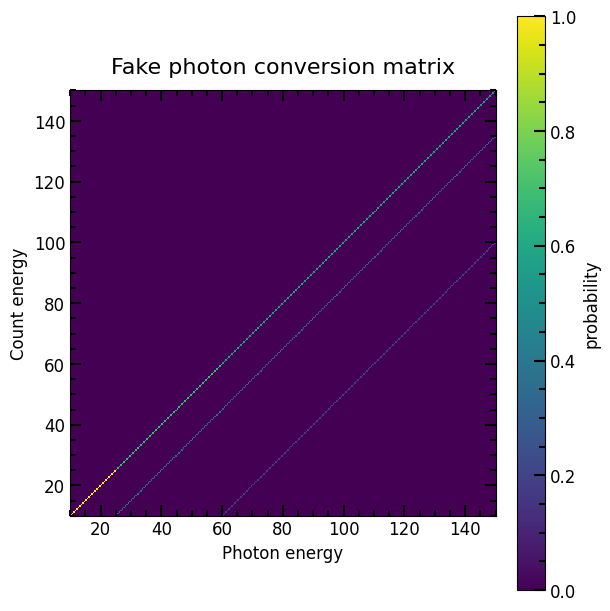

In [2]:
# Construct photon energy bins
de = 0.5
bins = np.arange(10, 150 + de, de)
size = bins.size - 1

# Make a fake redistribution matrix with some off-diagonal terms
example = np.eye(size)
np.fill_diagonal(example[:, 30:], 0.5)
np.fill_diagonal(example[:, 100:], 0.3)

# The probabilities should still sum to <= 1 along each column: we have escape peaks now
example = example / example.sum(axis=0)

fig, ax = plt.subplots(figsize=(6, 6))
pcm = ax.pcolormesh(bins, bins, example)
ax.set_aspect(1)
ax.set(
    aspect=1,
    title="Fake photon conversion matrix",
    xlabel="Photon energy",
    ylabel="Count energy"
)
fig.colorbar(pcm, label='probability')
plt.show()

In [3]:
# The energies and FWHMs that we will fit.
# These actually correspond to a YAP scintillator. Not bad!
energies = [31, 60, 122] << u.keV
fwhms = [27.5, 18, 13] << u.percent
# Assume 5% uniform error on the FWHMs
fwhm_error = fwhms * 0.05

# The data are automatically fitted with the ~ 1/sqrt(E) function
ereln = detection.SqrtEnergyResolution(
    reference_fwhms=fwhms, fwhm_errors=fwhm_error, reference_energies=energies
)

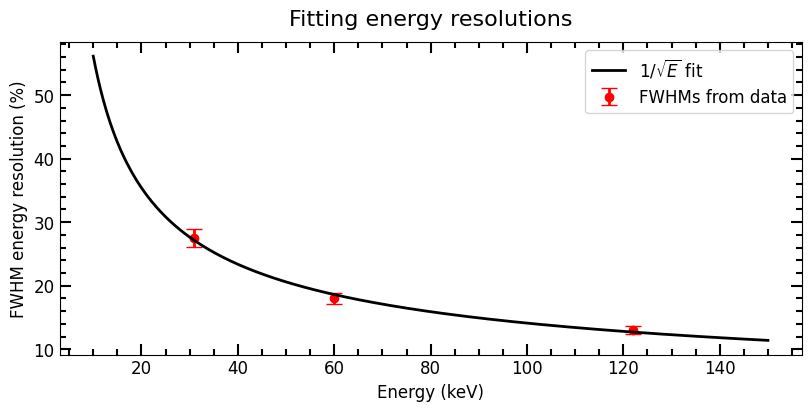

In [4]:
# Plot the energy resolution function to see how good the fit is
fig, ax = plt.subplots()

with quantity_support():
    ax.errorbar(
        energies,
        fwhms,
        yerr=fwhm_error,
        color="red",
        label="FWHMs from data",
        marker=".",
        ms=12,
        capsize=6,
        ls="None",
        zorder=-1,
    )

energy_range = bins
ax.plot(
    energy_range,
    # Evaluate the energy resolution (convert it to percent)
    100 * ereln.resolution_function(energy_range),
    label=r"$1 / \sqrt{E}$ fit",
    color="black",
)

ax.legend()
ax.set(
    ylabel="FWHM energy resolution (%)",
    xlabel="Energy (keV)",
    title="Fitting energy resolutions",
)

plt.show()

In [5]:
# Compute the resolution matrix f_ij
resolution_matrix = ereln.generate_resolution_matrix(bins << u.keV)

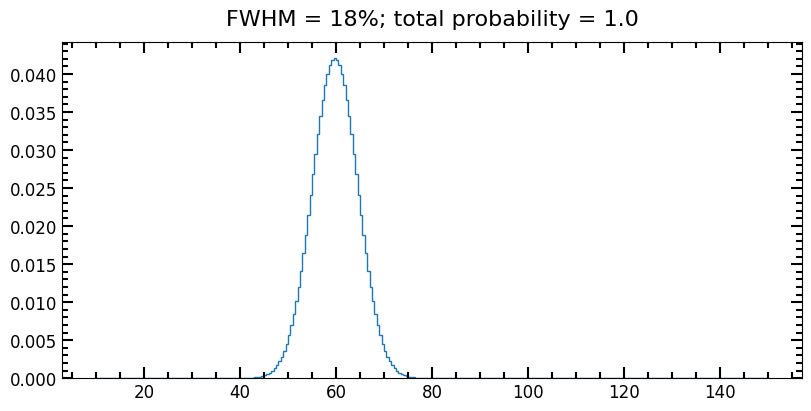

In [6]:
# Double check that we have ~the same resolution in the matrix
# as we do in the data we supplied
mids = bins[:-1] + np.diff(bins) / 2
# Look at the 60 keV number
idx = np.argmin(np.abs(mids - 60))
test = resolution_matrix[idx]

max_idx = test.argmax()
top_idx = np.argmin(np.abs(test - (test.max() / 2)))
fwhm = 2 * (mids[max_idx] - mids[top_idx]) / mids[max_idx]

fig, ax = plt.subplots()
ax.stairs(test, bins)
ax.set(title=f"FWHM = {100 * fwhm:.0f}%; total probability = {test.sum():.1f}")
plt.show()

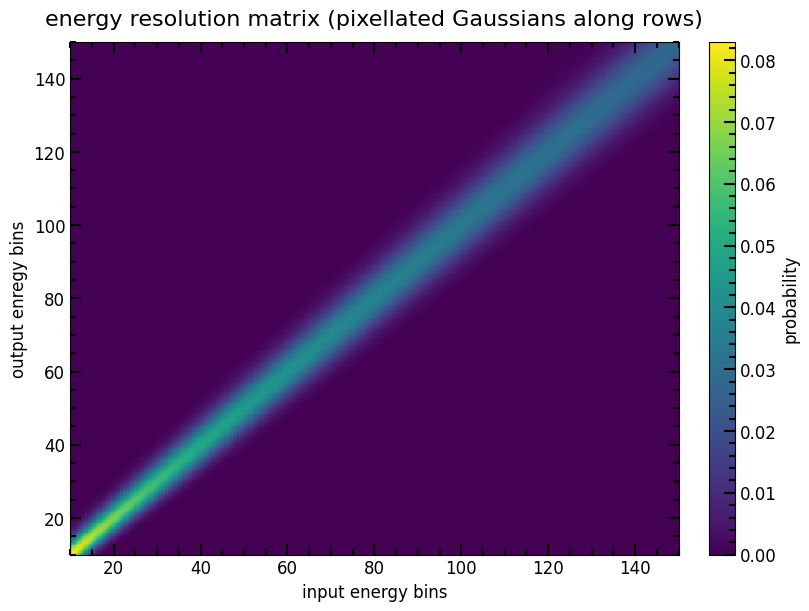

In [7]:
# Plot the resolution matrix
fig, ax = plt.subplots(figsize=(8, 6))
pcm = ax.pcolormesh(energy_range, energy_range, resolution_matrix)
ax.set(
    xlabel="input energy bins",
    ylabel="output enregy bins",
    title="energy resolution matrix (pixellated Gaussians along rows)",
)
_ = fig.colorbar(pcm, label="probability")
plt.show()

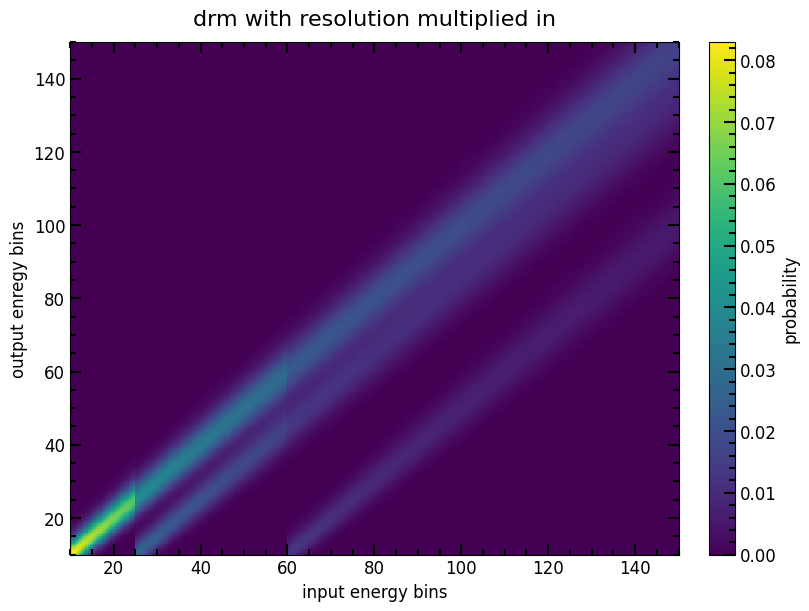

In [8]:
# Plot the resolution matrix multiplied into the redistribution matrix
fig, ax = plt.subplots(figsize=(8, 6))
pcm = ax.pcolormesh(energy_range, energy_range, (drm := resolution_matrix @ example))
ax.set(
    xlabel="input energy bins",
    ylabel="output enregy bins",
    title="drm with resolution multiplied in",
)
_ = fig.colorbar(pcm, label="probability")
plt.show()

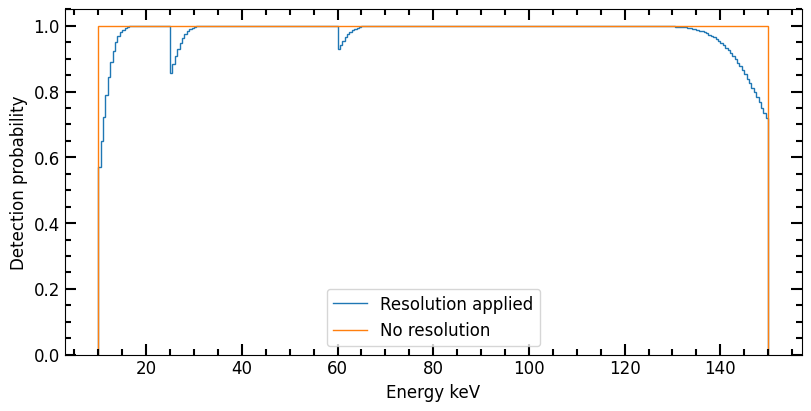

In [9]:
# Look at the effect of the energy resolution on the absorption edges,
# and the edges of the energy range

fig, ax = plt.subplots()
ax.stairs(drm.sum(axis=0), energy_range, label="Resolution applied")
ax.stairs(example.sum(axis=0), energy_range, label="No resolution")
ax.set(xlabel="Energy keV", ylabel="Detection probability")
ax.legend()
plt.show()